# PCA + Machine Learning: Practical Use

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="target"
)

print("Shape:", X.shape)

Shape: (569, 30)


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

In [4]:
from sklearn.decomposition import PCA

pca_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("model", LogisticRegression(max_iter=1000))
])

In [5]:
models = {
    "Logistic Regression": baseline_model,
    "Logistic Regression + PCA": pca_model
}

for name, model in models.items():
    model.fit(X_train, y_train)

print("All models trained.")

All models trained.


In [6]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, model in models.items():

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_f1 = f1_score(y_train, y_train_pred)

    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    f1_gap = train_f1 - test_f1

    results.append({
        "Model": name,
        "Train F1": train_f1,
        "Test F1": test_f1,
        "Accuracy": test_accuracy,
        "Precision": test_precision,
        "Recall": test_recall,
        "F1 Gap": f1_gap
    })

In [7]:
comparison = pd.DataFrame(results)

comparison

,Model,Train F1,Test F1,Accuracy,Precision,Recall,F1 Gap
0,Logistic Regression,0.991274,0.986111,0.982456,0.986111,0.986111,0.005163
1,Logistic Regression + PCA,0.991274,0.979021,0.973684,0.985915,0.972222,0.012253


In [8]:
from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    )

    cv_results.append({
        "Model": name,
        "Mean CV F1": scores.mean(),
        "Std CV F1": scores.std()
    })

In [9]:
cv_comparison = pd.DataFrame(cv_results)

final_comparison = comparison.merge(
    cv_comparison,
    on="Model"
)

final_comparison

,Model,Train F1,Test F1,Accuracy,Precision,Recall,F1 Gap,Mean CV F1,Std CV F1
0,Logistic Regression,0.991274,0.986111,0.982456,0.986111,0.986111,0.005163,0.984344,0.010069
1,Logistic Regression + PCA,0.991274,0.979021,0.973684,0.985915,0.972222,0.012253,0.982605,0.007683


In [10]:
pca_model.fit(X_train, y_train)

pca_step = pca_model.named_steps["pca"]

print("Original features:", X.shape[1])
print("Components kept:", pca_step.n_components_)
print(
    "Variance retained:",
    pca_step.explained_variance_ratio_.sum()
)

Original features: 30
Components kept: 10
Variance retained: 0.9526768937417542


In [11]:
X_train_scaled = pca_model.named_steps["scaler"].transform(X_train)

X_train_pca = pca_model.named_steps["pca"].transform(
    X_train_scaled
)

print("Before PCA:", X_train_scaled.shape)
print("After PCA:", X_train_pca.shape)

Before PCA: (455, 30)
After PCA: (455, 10)


In [12]:
pca_2d = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2))
])

X_2d = pca_2d.fit_transform(X_train)

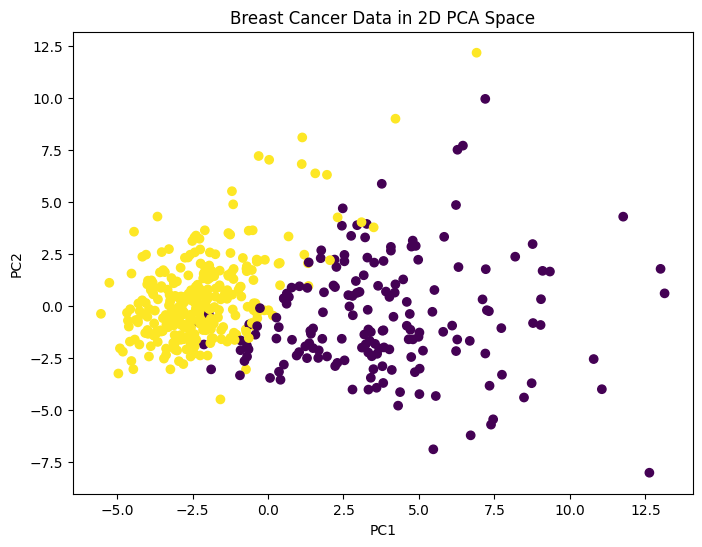

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=y_train
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Breast Cancer Data in 2D PCA Space")

plt.show()